<a href="https://colab.research.google.com/github/lorenzotomada/Applied_Mathematics/blob/main/Code/AM_lab2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Introduction to numpy:**
Please see the slides available at https://github.com/mgirfogl/numerical-analysis-2023-2024/blob/main/material/08-PS-Exercises-python-interpolation/Numpy_Scipy_Python.pdf for more info. Both this section and the one regarding Matplotlib do not contain the same amount of information which can be found in the PDF file linked above.

In [85]:
import numpy as np # To use just np. instead of numpy.
# ndim: number of axes
# shape: tuple of integers indicarting he size in each dimension
# size =total #  of elements
a = np.array([6,7,8])
b= np.array([[1., 0., 0.],[1.1, 3.1, 0.0]])
print(b)

# Common error a = np.array(...) ---> use square brackets
# zeros, ones to create an array of only zero/one elements
z = np.zeros((3,4))
print(z)
o = np.ones((2,3,4)) # You can specify the type of elemtn in the array
print(o)
lunghezza = 20
k1 = np.arange(3, lunghezza, 4) # You can build an array from 3 to lunghezza-1 with step 4
print(k1)
k2 = np. arange(0,2,0.3)
# 0 default start, 1 default step, if not specified.
a = np.random.random((2,3))
print(a.sum()) # a.sum() yields the sum of all the elements of the array
a.min()
a.max()
# b = np.arange(12).reshape((3,4)) # Now it has 3 rows and 4 columns.
# Pay attention to the number we put. (3,2) gives an error: 3*2=6, while we have 12 elements, so we cannot reshape.
b.min(axis=1) # min along the 2nd axis.
# To access elements: [] operator.
a[0,2] #or a[0][2], it is the same.
# Array slicing: see the notes for a more detailed explanation.
# a[:6:2] = -3 #it puts -3 in each of these positionas
# a[2:5] #elements from index 2 to 5-1
# a[::-1] #to revers a

# Use comma, index for each axis
# b[2,3]
# b[0:3,1] #each row in the second column


# You can also manipulate your arrays

# a.reshape gives automatically the right dimension
# a.resize changes the original one!
# a<35 # Is each element < 35?

[[1.  0.  0. ]
 [1.1 3.1 0. ]]
[[0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]]
[[[1. 1. 1. 1.]
  [1. 1. 1. 1.]
  [1. 1. 1. 1.]]

 [[1. 1. 1. 1.]
  [1. 1. 1. 1.]
  [1. 1. 1. 1.]]]
[ 3  7 11 15 19]
2.6811259559029055


0.7966632751611838

# **Matplotlib:**
Used to visualize data.

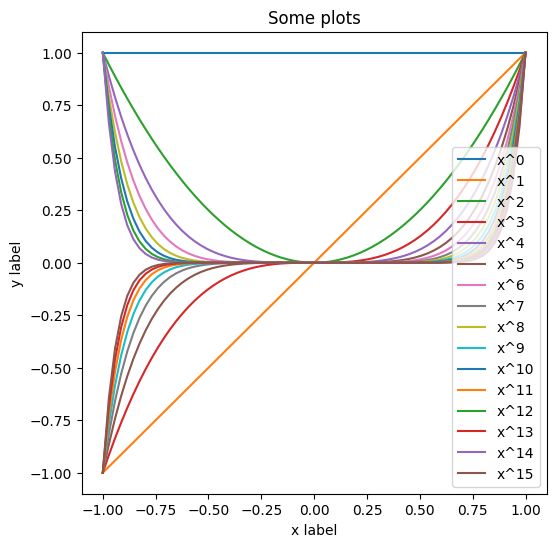

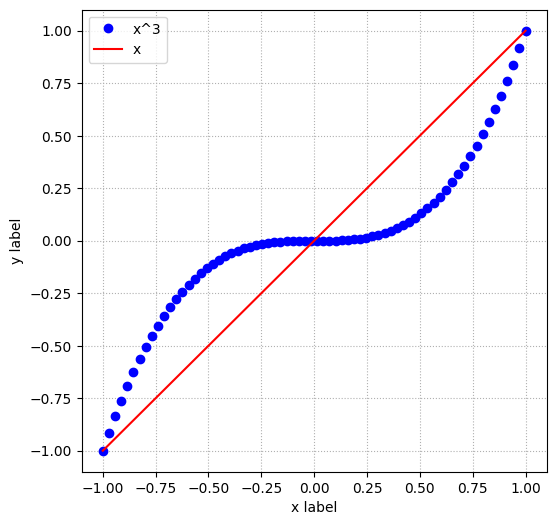

In [86]:
import matplotlib.pyplot as plt
# plt.plot(x,y)
# plt.show() ----> only to visualize a figure. We'll see how to save it. PDF, ...
# PDF ---> good quality, good e.g. for papers.
# You have control over all parts of the figure: title, lines, markers  (scatterplot), legend, grid, label of the figure...

x=np.linspace(-1,1,70) # It divides the interval (-1,1) in n+1 subintervals (all the points of the grid are equispaced).
for i in range(0,16):
  plt.plot(x,x**i,label='x^'+str(i)) # Plotting the function x^i for some values of i
plt.xlabel('x label') # Adding the x-label
plt.ylabel('y label') # Adding the y-label
plt.legend() # Adding the legend
plt.title('Some plots') # Adding the title
plt.show() # To show the plot

plt.plot(x, x**3, 'bo', label='x^3') # 'bo' ----> to see just the points
plt.plot(x, x, 'r-', label='x') # Red
plt.xlabel('x label')
plt.ylabel('y label')
plt.legend()
plt.grid(linestyle='dotted') # To see the grid
plt.savefig('myplot.pdf') # To save the figure
plt.show()

To see a gallery of plots, visit https://matplotlib.org/gallery/index.html. When you like some plot, you can see the code for it and adjust it to your problem with (hopefully) minor tweaks.

# **Polynomial interpolation:**
To have more theoretical info, see https://github.com/mgirfogl/numerical-analysis-2023-2024/blob/main/material/08-PS-Exercises-python-interpolation/Interpolation.pdf.

Lagrange basis -----> best choice! Today with monomial basis.

Populating the interactive namespace from numpy and matplotlib


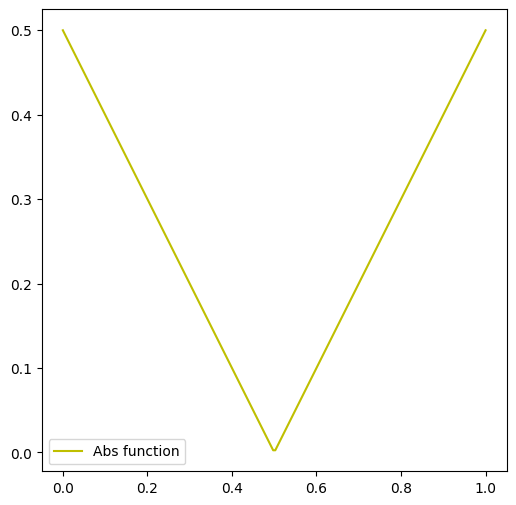

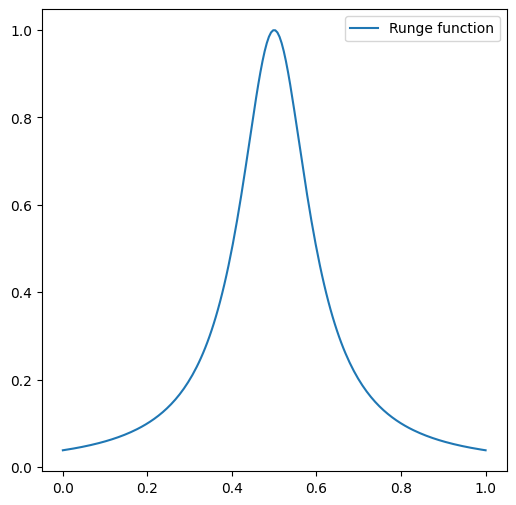

In [87]:
%pylab inline
# So we can use array instead of np.array
# Populating the interactive namespace from numpy and matplotlib

def my_fun1(x):
  return abs(x-0.5) # Considering the interval [0,1]; absolute value function.

def my_fun2(x):
  return 1/(1+100*(x-0.5)**2) # Runge funtion.

x=linspace(0,1,200)

plot(x,my_fun1(x), 'y-', label = 'Abs function')
plt.legend()
plt.show()

plot(x, my_fun2(x), label = 'Runge function')
plt.legend()
plt.show()


Text(0.5, 1.0, 'Interpolation points')

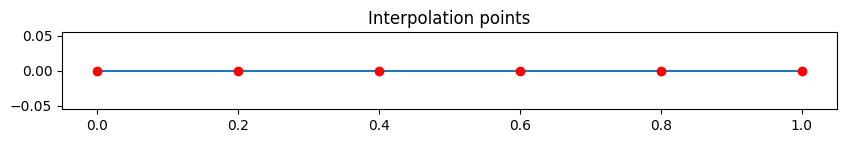

In [88]:
# Building the interpolation points:
n = 5 # Degree of the polynomial.
X = linspace(0, 1, n+1)
figsize(10,1) # To resize the figure.
plot(x, 0*x) # To plot the x axis.
plot(X, 0*X, 'ro')
title('Interpolation points')

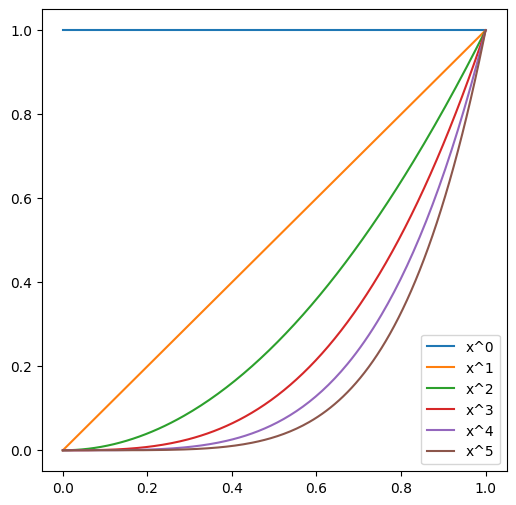

In [89]:
# Building the basis:
def basis(x,i,n): #v_i(x); it does not actually use n explicitly.
  """
  Monomial basis
  n is the order of the polynomial
  i is a number between 0 and n
  """
  return x**i

# Visualizing the basis:
figsize(6,6)
for i in range(n+1):
  plot(x,basis(x,i,n), label='x^'+str(i)) # Plotting the basis.
legend()

In [90]:
# Building the Vandermonde matrix:
# V=zeros((n+1, n+1)) # Initialize with all zeroes.
# for i in range(n+1):
#  for j in range(n+1):
 #   V[i,j]=basis(X[i], j, n)

# Actually we could write:
V = array([[basis(X[i],j,n) for j in range(n+1)] for i in range(n+1)]) # More effficient way to build it.

(200, 6)

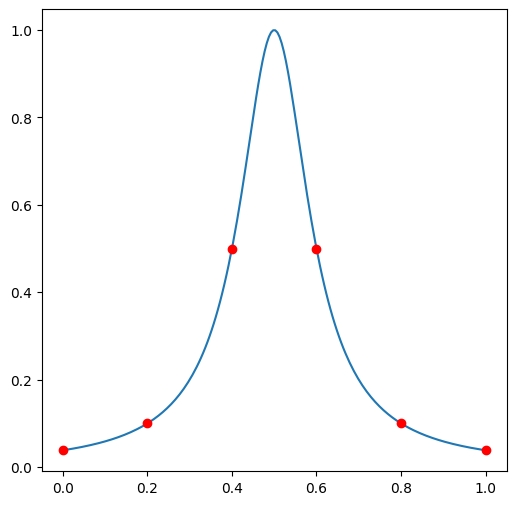

In [91]:
u = my_fun2(X) # Evaluating our function on interpolation points.
# To solve the linear system:
p = solve(V,u) # To solve the system Vp=u to find the coefficients p.
plot(x,my_fun2(x))
plot(X, V.dot(p), 'ro') # Evaluating the product. Actually, we could have just written:
# plot(X, my_fun2(X),'ro') # which does the same exact thing, taking the values of the function on X instead of doing more computations.
# Building the matrix to visualize the polynomial.
B = array([[basis(x[i],j,n) for j in range(n+1)] for i in range(len(x))]) # Evaluating the basis functions on the grid.
B.shape

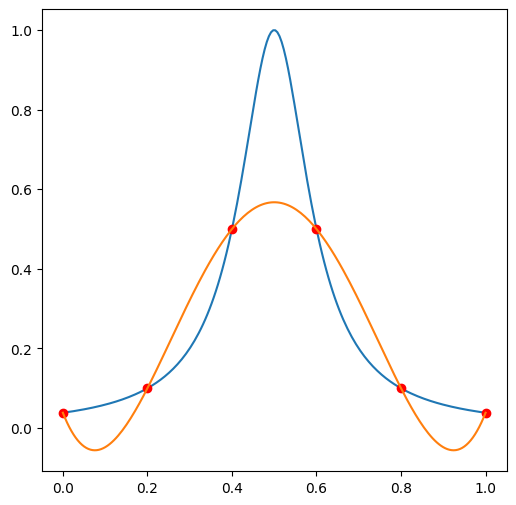

In [92]:
plot(x,my_fun2(x)) # Plotting the function.
plot(X,V.dot(p),'ro') # Plotting the points.
plot(x,B.dot(p)) # Plotting the polynomial.

In [93]:
error = np.max(abs(B.dot(p)-my_fun2(x)))
print(error)

cond(V) # Condition number of the matrix V. The Vandermonde matrix is bad-conditioned.

0.4321051132111742


4924.3710566111995

What happens increasing the degree of the polynomial?

If we try with n = 10, we see a bad situation, the error tends to increase, as we have a lot of oscillations.

For n = 25 the situation becomes "tragic".


(200, 6)


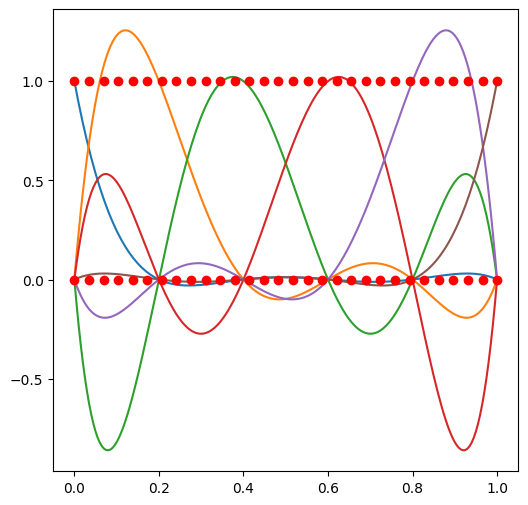

In [98]:
# Computing the lagrange basis from the monomial basis and plotting it:
Vinv = inv(V) # Computing the inverse of V.
Bl = B.dot(Vinv) # Computing the product of B and the inverse of V.
print(Bl.shape)
plot(x,Bl[:,:]) # plot(x,Bl[:,0]) # To plot only the first  element of Lagrange's basis.
plot(X,0*X,'ro') # Plotting the points (0, 0), (0, 0.2), ...
plot(X,0*X+1,'ro') # Plotting the points (1, 0), (1, 0.2), ...


Condition number of V:  4924.3710566111995


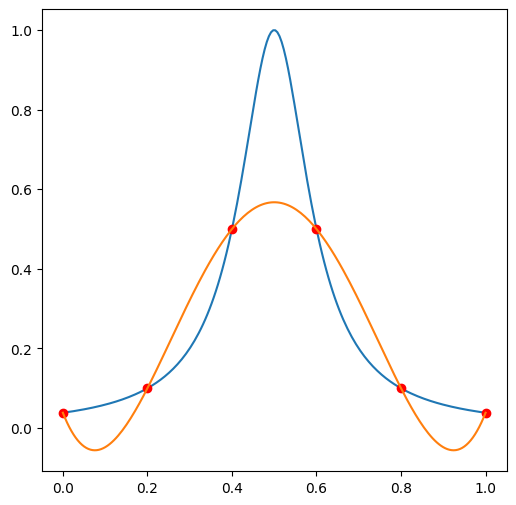

In [95]:
# Defining a function for the interpolation:
def interpolation(fun, X, x): # Taking as input the interval, the points on which we interpolate and the function.
  n = len(X) - 1 # The degree is one less of the number of points.
  V = array([[basis(X[i],j,n) for j in range(n+1)] for i in range(n+1)]) # We create the matrix.
  print("Condition number of V: ", cond(V)) # We print the condition number of the matrix.
  B = array([[basis(x[i],j,n) for j in range(n+1)] for i in range(len(x))]) # B as before, we evaluate the basis in the grid points.
  p = solve(V, fun(X))
  return B.dot(p), p, B, V

# Checking the results by plotting our functions:
plot(x, my_fun2(x))
plot(X, my_fun2(X),'ro')
plot(x, interpolation(my_fun2,X,x)[0])

Condition number of V:  98.86773850722771
Condition number of V:  98.86773850722771
Condition number of V:  686.4349418185955
Condition number of V:  686.4349418185955
Condition number of V:  4924.3710566111995
Condition number of V:  4924.3710566111995
Condition number of V:  36061.16088021232
Condition number of V:  36061.16088021232
Condition number of V:  267816.7009077296
Condition number of V:  267816.7009077296
Condition number of V:  2009396.3800388556
Condition number of V:  2009396.3800388556
Condition number of V:  15193229.67628169
Condition number of V:  15193229.67628169
Condition number of V:  115575244.55779406
Condition number of V:  115575244.55779406
Condition number of V:  883478686.4514534
Condition number of V:  883478686.4514534
Condition number of V:  6780588494.9134035
Condition number of V:  6780588494.9134035
Condition number of V:  52214927445.877914
Condition number of V:  52214927445.877914
Condition number of V:  403234907001.93036
Condition number of V: 

Text(0, 0.5, 'Error')

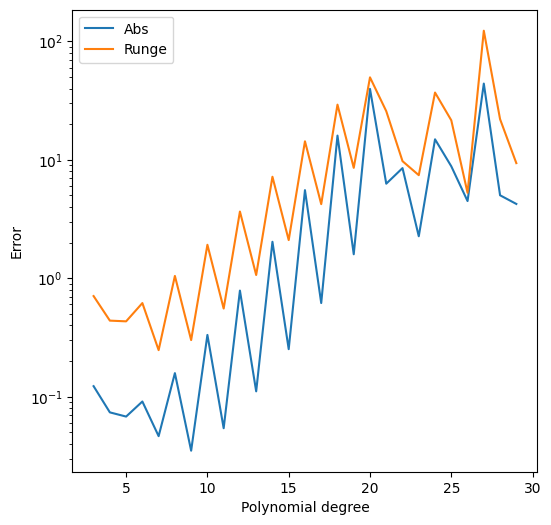

In [97]:
# Seeing the error of the interpolation as the degree of the polynomial increases:
error1 = [] # Error of the absolute value function.
error2 = [] # Error of Runge's function.
N = range(3,30)
for n in N:
  X = linspace(0,1,n+1)
  error1.append(np.max(abs(interpolation(my_fun1,X,x)[0]-my_fun1(x)))) # Updating the error list.
  error2.append(np.max(abs(interpolation(my_fun2,X,x)[0]-my_fun2(x))))
plot(N,error1,label='Abs')
plot(N,error2,label='Runge')
yscale('log') # Log-scale, better for plotting the error.
legend()
xlabel('Polynomial degree')
ylabel('Error')